In [2]:
%pip install numpy
%pip install missingno matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

data_raw=pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

# xem 5 record dau tien
print(data_raw.head())

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


In [4]:
# Xem kieu du lieu cua cac cot
print(data_raw.dtypes)

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object


In [5]:
# Thong ke so bo ve du lieu cua tung cot
display(data_raw.describe(include='all'))

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
count,61,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204,48204,48204.000000
unique,11,NaN,NaN,NaN,NaN,11,38,40575,NaN
top,Labor Day,NaN,NaN,NaN,NaN,Clouds,sky is clear,2013-05-19 10:00:00,NaN
freq,7,NaN,NaN,NaN,NaN,15164,11665,6,NaN
mean,NaN,281.205870,0.334264,0.000222,49.362231,NaN,NaN,NaN,3259.818355
std,NaN,13.338232,44.789133,0.008168,39.015750,NaN,NaN,NaN,1986.860670
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000
25%,NaN,272.160000,0.000000,0.000000,1.000000,NaN,NaN,NaN,1193.000000
50%,NaN,282.450000,0.000000,0.000000,64.000000,NaN,NaN,NaN,3380.000000
75%,NaN,291.806000,0.000000,0.000000,90.000000,NaN,NaN,NaN,4933.000000


<Figure size 1600x1200 with 0 Axes>

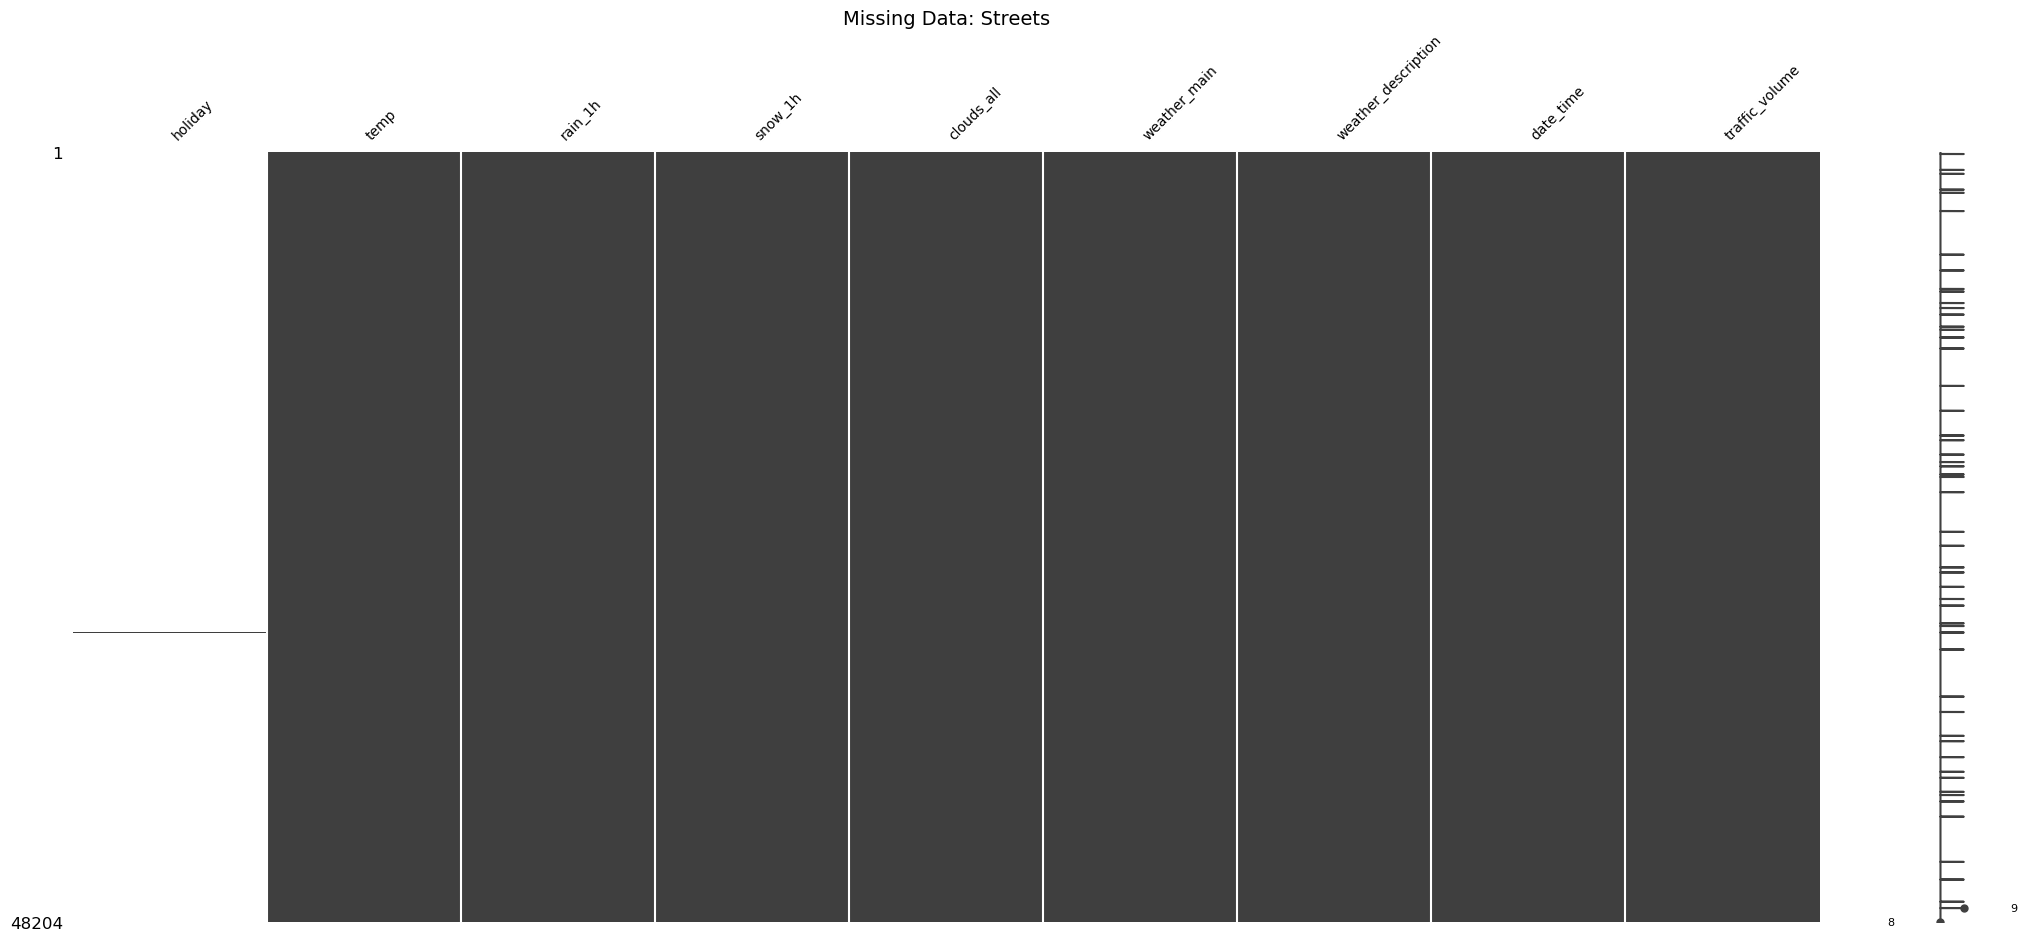

In [6]:
# kiem tra missing data
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

msno.matrix(data_raw, sparkline=True, fontsize=10)

plt.title("Missing Data: Streets", fontsize=14)

plt.show()

In [7]:
# Kiểm tra số lượng và tỷ lệ % missing value cụ thể của từng cột
missing_data = data_raw.isnull().sum()
missing_percent = (data_raw.isnull().sum() / len(data_raw)) * 100

# Gộp thành bảng để dễ quan sát
missing_df = pd.DataFrame({'Số dòng thiếu': missing_data, 'Tỷ lệ %': missing_percent})
print(missing_df)

                     Số dòng thiếu    Tỷ lệ %
holiday                      48143  99.873454
temp                             0   0.000000
rain_1h                          0   0.000000
snow_1h                          0   0.000000
clouds_all                       0   0.000000
weather_main                     0   0.000000
weather_description              0   0.000000
date_time                        0   0.000000
traffic_volume                   0   0.000000


In [8]:
data_raw['date_time'] = pd.to_datetime(data_raw['date_time'])

# =====================================================================
# PHẦN 1: KIỂM TRA DỮ LIỆU TRÙNG LẶP (Giữ nguyên kiểm tra trùng lặp)
# =====================================================================
print("--- KIỂM TRA TRÙNG LẶP (ĐẾN GIỜ:PHÚT:GIÂY) ---")
total_duplicates = data_raw['date_time'].duplicated().sum()
print(f"Tổng số dòng bị trùng lặp thời gian: {total_duplicates}")

if total_duplicates > 0:
    print(f"Hiển thị toàn bộ {total_duplicates} dòng bị trùng lặp:")
    all_duplicates = data_raw[data_raw['date_time'].duplicated(keep=False)].sort_values(by='date_time')
    print(all_duplicates)


# =====================================================================
# PHẦN 2: LIỆT KÊ TOÀN BỘ KHOẢNG ĐỨT ĐOẠN > 1 GIỜ
# =====================================================================
print("\n--- LIỆT KÊ TOÀN BỘ KHOẢNG ĐỨT ĐOẠN (> 1 GIỜ) ---")

# Sắp xếp chuỗi thời gian tăng dần
df_sorted = data_raw.sort_values(by='date_time').copy()

# Tính khoảng cách thời gian giữa dòng sau và dòng trước
df_sorted['time_diff'] = df_sorted['date_time'].diff()

# Đặt mốc thời gian giới hạn là đúng 1 giờ
one_hour = pd.Timedelta(hours=1)

# LỌC LẠI: Chỉ lấy những vị trí có khoảng cách thời gian LỚN HƠN 1 GIỜ
gaps_mask = df_sorted['time_diff'] > one_hour
df_gaps_raw = df_sorted[gaps_mask]

print(f"Tổng số vị trí chuỗi thời gian bị đứt gãy > 1 giờ: {len(df_gaps_raw)}")

if len(df_gaps_raw) > 0:
    # Tạo DataFrame chứa thông tin chi tiết các khoảng hổng lớn hơn 1h
    df_all_gaps = pd.DataFrame({
        'Từ thời điểm': df_gaps_raw['date_time'] - df_gaps_raw['time_diff'],
        'Đến thời điểm': df_gaps_raw['date_time'],
        'Khoảng hổng (Thời gian mất)': df_gaps_raw['time_diff']
    }).reset_index(drop=True)
    
    # Cấu hình Pandas hiển thị toàn bộ dòng dữ liệu kết quả
    pd.set_option('display.max_rows', None) 
    
    print("\nDanh sách TOÀN BỘ các khoảng thời gian bị ngắt quãng lớn hơn 1 giờ:")
    print(df_all_gaps)
    
    # Khôi phục cấu hình hiển thị mặc định của Pandas
    pd.reset_option('display.max_rows')

--- KIỂM TRA TRÙNG LẶP (ĐẾN GIỜ:PHÚT:GIÂY) ---
Tổng số dòng bị trùng lặp thời gian: 7629
Hiển thị toàn bộ 7629 dòng bị trùng lặp:
      holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
178       NaN  281.25      0.0      0.0          99         Rain   
179       NaN  281.25      0.0      0.0          99      Drizzle   
180       NaN  280.10      0.0      0.0          99         Rain   
181       NaN  280.10      0.0      0.0          99      Drizzle   
182       NaN  279.61      0.0      0.0          99         Rain   
...       ...     ...      ...      ...         ...          ...   
48173     NaN  280.68      0.0      0.0          90       Clouds   
48192     NaN  283.48      0.0      0.0          90         Rain   
48193     NaN  283.48      0.0      0.0          90      Drizzle   
48194     NaN  283.84      0.0      0.0          75         Rain   
48195     NaN  283.84      0.0      0.0          75      Drizzle   

           weather_description           date_time  t

In [9]:
data_raw['date_time'] = pd.to_datetime(data_raw['date_time'])

# Sắp xếp chuỗi thời gian tăng dần để đảm bảo tính tuần tự
df_sorted = data_raw.sort_values(by='date_time').copy()

# =====================================================================
# XỬ LÝ GOM CỤM (GAPS AND ISLANDS)
# =====================================================================

# Kỷ lục khoảng cách giữa các dòng liên tiếp
df_sorted['time_diff'] = df_sorted['date_time'].diff()

# Đánh dấu True nếu khoảng cách lớn hơn 1 giờ (phát hiện điểm đứt gãy)
# Dòng đầu tiên (NaN) mặc định coi là False để không tự tăng ID
is_gap = df_sorted['time_diff'] > pd.Timedelta(hours=1)

# Hàm cumsum() sẽ tăng 1 đơn vị mỗi khi gặp True. 
# Các dòng liên tục (False) sẽ nhận chung một giá trị ID.
df_sorted['cluster_id'] = is_gap.cumsum()

# =====================================================================
# THỐNG KÊ VÀ TÌM ĐOẠN LIÊN TỤC DÀI NHẤT
# =====================================================================

# Gom nhóm theo cluster_id để tính toán thông tin từng cụm
clusters = df_sorted.groupby('cluster_id').agg(
    Thoi_Gian_Bat_Dau=('date_time', 'min'),
    Thoi_Gian_Ket_Thuc=('date_time', 'max'),
    So_Luong_Dong=('date_time', 'count')
).reset_index()

# Tìm cụm có số lượng dòng (bản ghi) lớn nhất
longest_cluster = clusters.loc[clusters['So_Luong_Dong'].idxmax()]

print("--- THÔNG TIN ĐOẠN LIÊN TỤC DÀI NHẤT ---")
print(f"Mã cụm (Cluster ID): {int(longest_cluster['cluster_id'])}")
print(f"Thời gian bắt đầu  : {longest_cluster['Thoi_Gian_Bat_Dau']}")
print(f"Thời gian kết thúc : {longest_cluster['Thoi_Gian_Ket_Thuc']}")
print(f"Tổng số bản ghi liên tục: {longest_cluster['So_Luong_Dong']} dòng (tương đương khoảng {longest_cluster['So_Luong_Dong']} giờ)")

# Tùy chọn: Nếu bạn muốn lấy TOÀN BỘ dữ liệu gốc của đoạn dài nhất này để phân tích tiếp:
df_longest_chunk = df_sorted[df_sorted['cluster_id'] == longest_cluster['cluster_id']]

--- THÔNG TIN ĐOẠN LIÊN TỤC DÀI NHẤT ---
Mã cụm (Cluster ID): 2564
Thời gian bắt đầu  : 2017-04-13 10:00:00
Thời gian kết thúc : 2017-07-02 04:00:00
Tổng số bản ghi liên tục: 2387 dòng (tương đương khoảng 2387 giờ)


<Figure size 1600x1200 with 0 Axes>

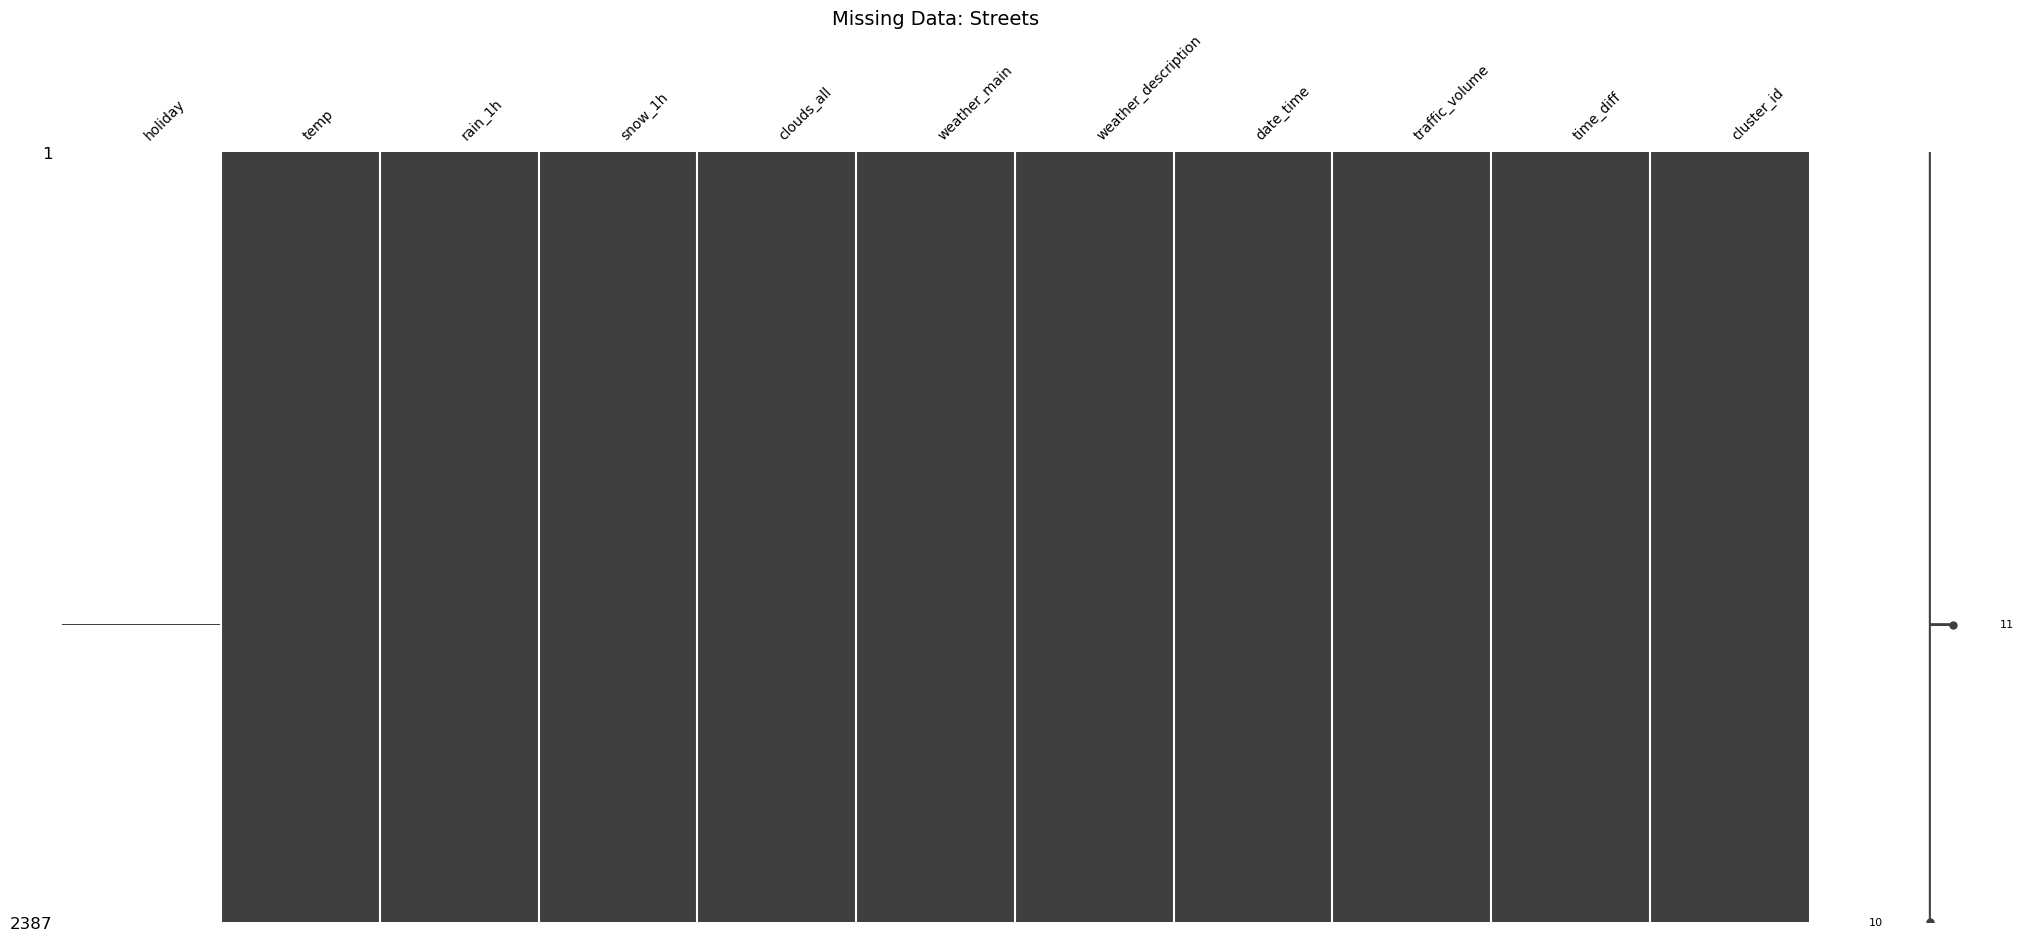

In [10]:
plt.figure(figsize=(16, 12))

msno.matrix(df_longest_chunk, sparkline=True, fontsize=10)

plt.title("Missing Data: Streets", fontsize=14)

plt.show()

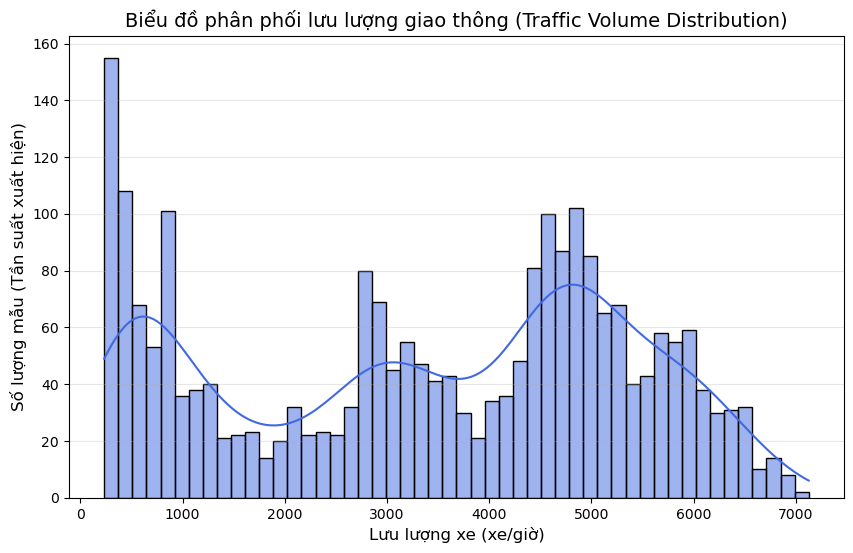

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# cau hinh kich thuoc bieu do
plt.figure(figsize=(10, 6))

# ve bieu do histogram cho cot 'traffic_volume'
sns.histplot(data=df_longest_chunk, x='traffic_volume', bins=50, kde=True, color='royalblue')
# them tieu de va nhan cho bieu do
plt.title('Biểu đồ phân phối lưu lượng giao thông (Traffic Volume Distribution)', fontsize=14)
plt.xlabel('Lưu lượng xe (xe/giờ)', fontsize=12)
plt.ylabel('Số lượng mẫu (Tần suất xuất hiện)', fontsize=12)

# hien thi bieu do
plt.grid(axis='y', alpha=0.3)
plt.show()

In [12]:
# nhan xet ve bieu do tren:
# - bieu do nay cos 3 dinh, tuong ung voi 3 nhom luu luong giao thong: nho, trung binh va lon
# - nhom nho (dinh thu nhat): day la luong xe luu thong vao nua dem (~ 300-500 xe/h), chiem so luong mau cao nhat (max = ~4000 mau)
# - nhom trung binh (dinh thu hai): dai dien cho nhom thap diem ban ngay, mac du luong xe cao hon (~2500-3000 xe/h) nhung chiem so luong mau thap hon (max = ~2000 mau)
# - nhom lon (dinh thu ba): dai dien cho nhom cao diem ban ngay, luong xe cao nhat (~4000-5000 xe/h) nhung chiem so luong mau thap nhat (max = ~1000 mau)
# ngoai ra, bieu do con ghi nhan 1 so mau co luong xe cao (>6500 xe/h), dai dien cho nhung case ket xe, dieu nau the hien ro vao cac ngay le.

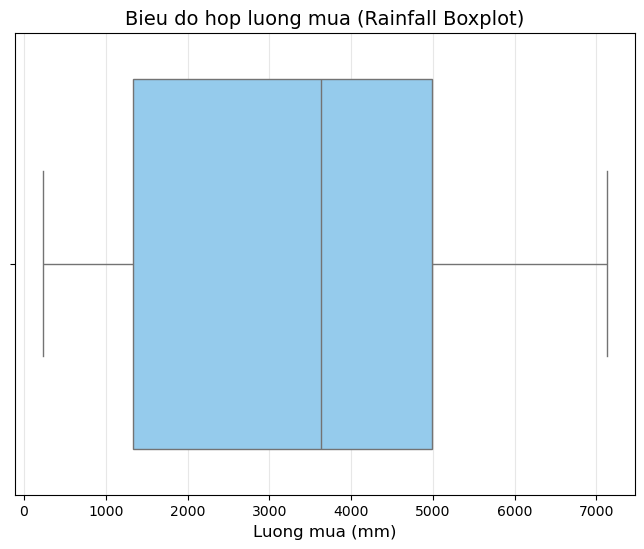

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cau hinh kich thuoc bieu do
plt.figure(figsize=(8, 6))

# Ve bieu do Boxplot cho luu luong giao thong
# Dung tham so x= de ve hop nam ngang, giup de quan sat cac moc gia tri
sns.boxplot(data=df_longest_chunk, x='traffic_volume', color='lightskyblue', flierprops={'markerfacecolor': 'red', 'marker': 'o'})
#sns.boxplot(data=df_longest_chunk, x='temp', color='lightskyblue', flierprops={'markerfacecolor': 'red', 'marker': 'o'})
#sns.boxplot(data=df_longest_chunk, x='rain_1h', color='lightskyblue', flierprops={'markerfacecolor': 'red', 'marker': 'o'})

# Them tieu de va nhan truc
plt.title('Bieu do hop luong mua (Rainfall Boxplot)', fontsize=14)
plt.xlabel('Luong mua (mm)', fontsize=12)

# Hien thi bieu do
plt.grid(axis='x', alpha=0.3)
plt.show()

In [15]:
df_longest_chunk.to_csv("data_refined.csv", index=False)

### QUY TRÌNH TIỀN XỬ LÝ DỮ LIỆU ĐỀ XUẤT (DATA PREPROCESSING)

**Mục tiêu:** Biến đổi tập dữ liệu thô thành tập dữ liệu chuỗi thời gian sạch, liên tục dưới dạng file `.csv` để huấn luyện mô hình.

1. **Lọc vùng dữ liệu ổn định:** Trích xuất phân đoạn dữ liệu liên tục từ năm 2017 đến 2018 nhằm đảm bảo tính toàn vẹn của chuỗi thời gian.
2. **Loại bỏ dữ liệu dị thường (Outliers):** - Xóa bỏ các dòng có nhiệt độ `temp = 0.00 K` (lỗi cảm biến).
   - Xóa bỏ các dòng có lượng mưa `rain_1h > 9.831 mm/h` (lỗi thiết bị đo).
3. **Xử lý trùng lặp thời gian:** Gom cụm (Groupby) các dòng có cùng mốc `date_time`. Tính giá trị trung bình (`mean`) cho các biến số và lấy giá trị phổ biến nhất (`mode`) cho các biến chữ.
4. **Xử lý mốc giờ bị khuyết (Missing Timestamps):** Tạo lại khung thời gian đầy đủ từng giờ và áp dụng phương pháp nội suy tuyến tính (`Linear Interpolation`) hoặc `Forward Fill` để điền đầy dữ liệu cho những giờ bị thiếu, giữ mạch thời gian liên tục thẳng tắp.
5. **Trích xuất đặc trưng (Feature Engineering):** Từ cột `date_time`, bóc tách thành các biến định lượng mới: `Hour` (Giờ trong ngày), `DayOfWeek` (Thứ trong tuần), `Month` (Tháng trong năm) và `Is_Weekend` (Có phải cuối tuần không) để mô hình học được quy luật sinh hoạt.
6. **Mã hóa biến phân loại (Encoding):** Chuyển đổi các cột dạng chữ như `weather_main` và `holiday` sang dạng số 0/1 bằng kỹ thuật `One-Hot Encoding`.
7. **Tạo biến trễ (Lag Features):** Tạo các cột giá trị quá khứ (`t-1`, `t-2`, `t-24`) trực tiếp trên biến mục tiêu `traffic_volume` để phục vụ cấu trúc thuật toán cửa sổ trượt (`Sliding Window`).
8. **Chuẩn hóa dữ liệu (Scaling):** Đưa dải dữ liệu về khoảng [0, 1] hoặc [-1, 1] để tối ưu tốc độ hội tụ và hiệu suất cho các thuật toán học máy.